<a href="https://colab.research.google.com/github/Jigyasa-2606/Feature-Extraction-and-Classification-of-Moving-Vehicles-on-Highways/blob/main/bilateral_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize']=[10,16]

In [3]:
import os
import cv2

video_dir = "/content/real_dataset"
frames_dir = "/content/real_frames"

os.makedirs(frames_dir, exist_ok=True)

frame_skip = 5

for video_name in os.listdir(video_dir):
    if not video_name.endswith(".mp4"):
        continue

    video_path = os.path.join(video_dir, video_name)
    cap = cv2.VideoCapture(video_path)

    count = 0
    saved = 0

    video_id = video_name.split(".")[0]

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % frame_skip != 0:
            count += 1
            continue

        frame = cv2.resize(frame, (256, 256))

        filename = f"{video_id}_frame_{saved:05d}.jpg"
        cv2.imwrite(os.path.join(frames_dir, filename), frame)

        saved += 1
        count += 1

    cap.release()
    print(f"{video_name} → {saved} frames extracted")

print("All videos processed ")

Dataset7.mp4 → 363 frames extracted
Dataset4.mp4 → 426 frames extracted
Dataset2.mp4 → 217 frames extracted
Dataset1.mp4 → 508 frames extracted
Dataset5.mp4 → 238 frames extracted
Dataset10.mp4 → 345 frames extracted
Dataset6.mp4 → 123 frames extracted
Dataset8.mp4 → 124 frames extracted
Dataset9.mp4 → 147 frames extracted
Dataset3.mp4 → 237 frames extracted
All videos processed 


In [4]:
import cv2
import os
from glob import glob

input_folder = "/content/real_frames"


def equalise_hist_color(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img_output = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    return img_output


image_paths = sorted(glob(os.path.join(input_folder, "*.jpg")))

processed_frames = []

for path in image_paths:
    img = cv2.imread(path)
    output = equalise_hist_color(img)

    processed_frames.append(output)

print("✅ All frames processed")

✅ All frames processed


In [5]:
def initialize_airmap(img, beta=0.9):
    img_c = img.astype('float32') / 255.0

    if img.ndim == 3:
        min_img = beta * np.min(img_c, axis=2)
    else:
        min_img = beta * img_c

    return min_img

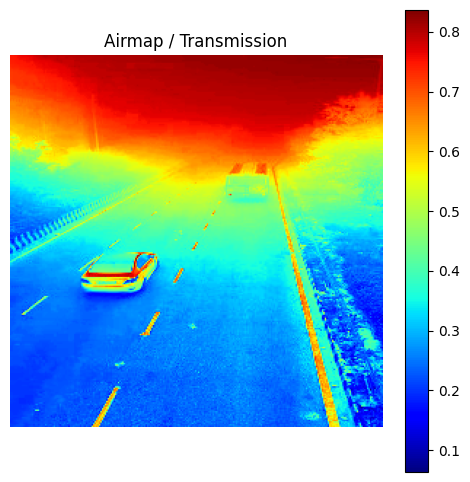

In [6]:
airmap = initialize_airmap(img)

plt.figure(figsize=(6,6))
plt.imshow(airmap, cmap='jet')
plt.colorbar()
plt.title("Airmap / Transmission")
plt.axis('off')
plt.show()

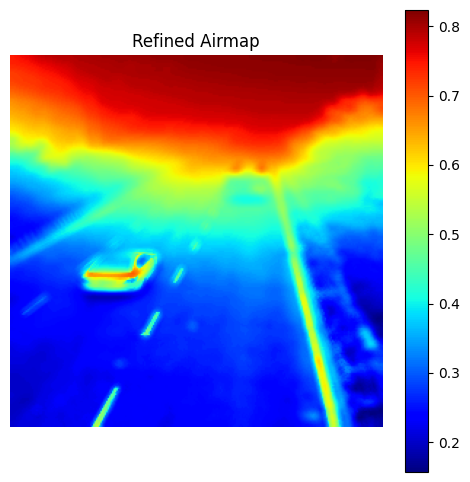

In [7]:
def refine_airmap(img):
    blur = cv2.bilateralFilter((img * 255).astype('uint8'), 9, 75, 75)
    return blur

refined_airmap = refine_airmap(airmap) / 255.0

plt.figure(figsize=(6,6))
plt.imshow(refined_airmap, cmap='jet')
plt.colorbar()
plt.title("Refined Airmap")
plt.axis('off')
plt.show()

In [8]:
def restoration(img, airmap, i_inf=1.0, t0=0.1):

    transmission = np.maximum(airmap, t0)

    J = (img - transmission) / (1.0 - transmission / i_inf)

    return np.clip(J, 0, 1)

In [9]:
b, g, r = cv2.split(img)

b_c = restoration(b/255.0, refined_airmap)
g_c = restoration(g/255.0, refined_airmap)
r_c = restoration(r/255.0, refined_airmap)

img_c = cv2.merge((b_c, g_c, r_c))
img_c = (np.clip(img_c, 0, 1) * 255).astype('uint8')

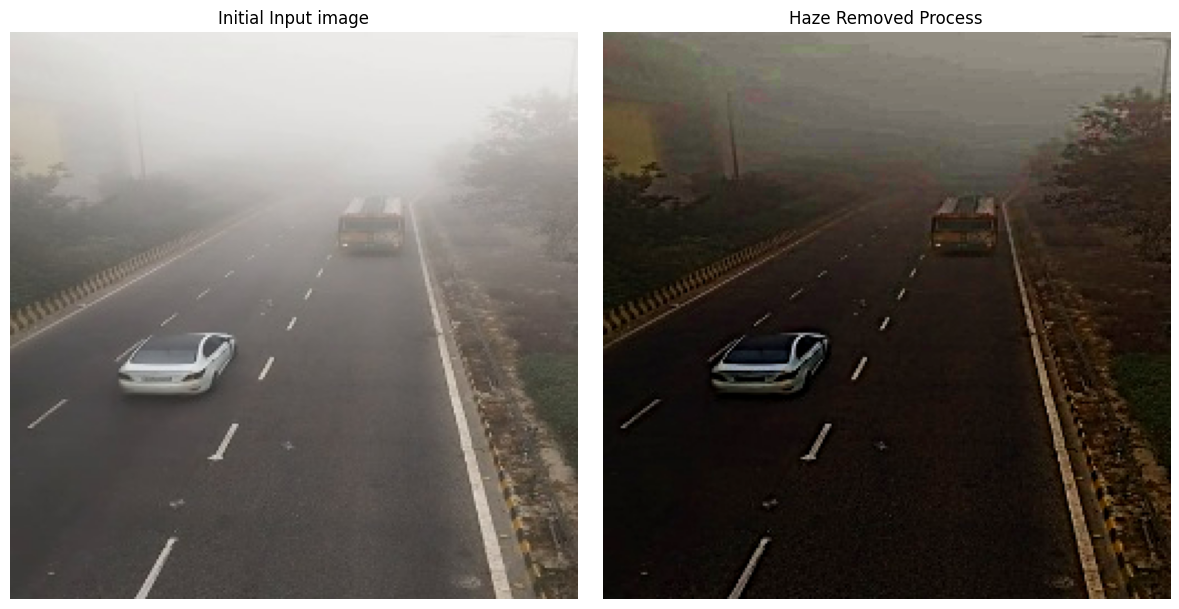

In [10]:
disp = np.hstack((img, img_c))

plt.figure(figsize=(12,6))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Initial Input image")
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))
plt.title("Haze Removed Process")
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
def transfer_function(img, r1, r2, s1, s2):
    img = img.astype(np.float32)

    r1 = max(r1, 1)
    r2 = max(r2, r1 + 1)
    r2 = min(r2, 254)

    out = np.zeros_like(img)


    mask1 = img < r1
    mask2 = (img >= r1) & (img <= r2)
    mask3 = img > r2

    out[mask1] = (s1 / r1) * img[mask1]
    out[mask2] = ((s2 - s1) / (r2 - r1)) * (img[mask2] - r1) + s1
    out[mask3] = ((255 - s2) / (255 - r2)) * (img[mask3] - r2) + s2

    return np.clip(out, 0, 255).astype('uint8')

In [12]:
def hist_stretch(img, r_min_per=0.1, r_max_per=0.9, s_min_per=0.05, s_max_per=0.95):
    img = img.astype('uint8')

    hist, _ = np.histogram(img, bins=256, density=True)
    cumulative = np.cumsum(hist)

    r1 = np.where(cumulative > r_min_per)[0][0]
    r2 = np.where(cumulative > r_max_per)[0][0]

    s1 = int(255 * s_min_per)
    s2 = int(255 * s_max_per)

    return transfer_function(img, r1, r2, s1, s2)

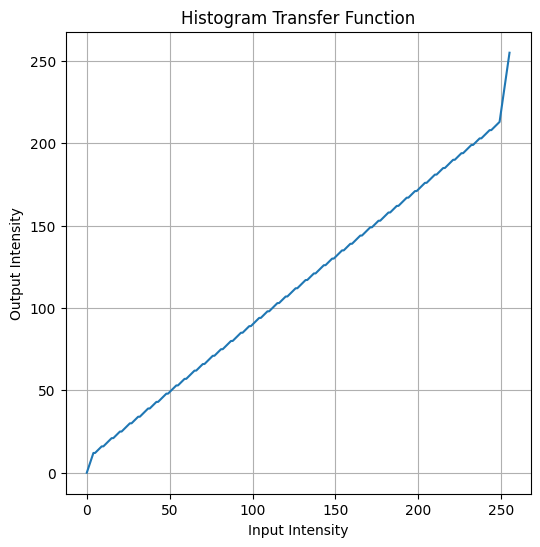

In [13]:
import numpy as np

x = np.arange(256)
total = transfer_function(x, 4, 249, 12, 213)

plt.figure(figsize=(6,6))
plt.title("Histogram Transfer Function")
plt.plot(x, total)
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()
plt.show()

In [14]:
def hist_stretch(img, r_min_per=0.1, r_max_per=0.9, s_min_per=0.05, s_max_per=0.95):

    img = img.astype('uint8')

    hist, _ = np.histogram(img, bins=256, density=True)
    cumulative = np.cumsum(hist)


    r1 = np.where(cumulative > r_min_per)[0][0]
    r2 = np.where(cumulative > r_max_per)[0][0]

    if r2 <= r1:
        r2 = r1 + 1


    r2 = min(r2, 254)
    r1 = max(r1, 1)

    s1 = int(255 * s_min_per)
    s2 = int(255 * s_max_per)

    return transfer_function(img, r1, r2, s1, s2)

In [15]:
img_yuv = cv2.cvtColor(img_c, cv2.COLOR_BGR2YUV)

y_channel = img_yuv[:, :, 0].astype('uint8')

y_channel = hist_stretch(y_channel)

img_yuv[:, :, 0] = y_channel

img_output = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

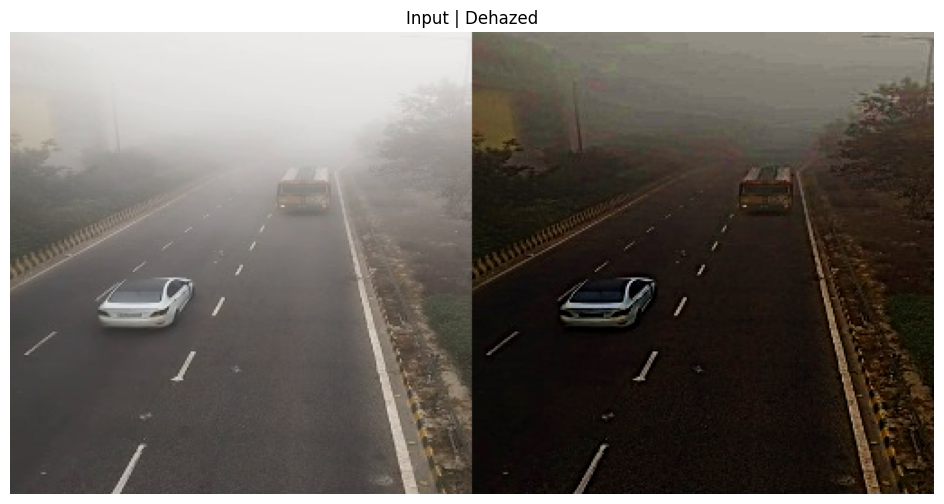

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
plt.title("Input | Dehazed")
plt.axis('off')
plt.show()

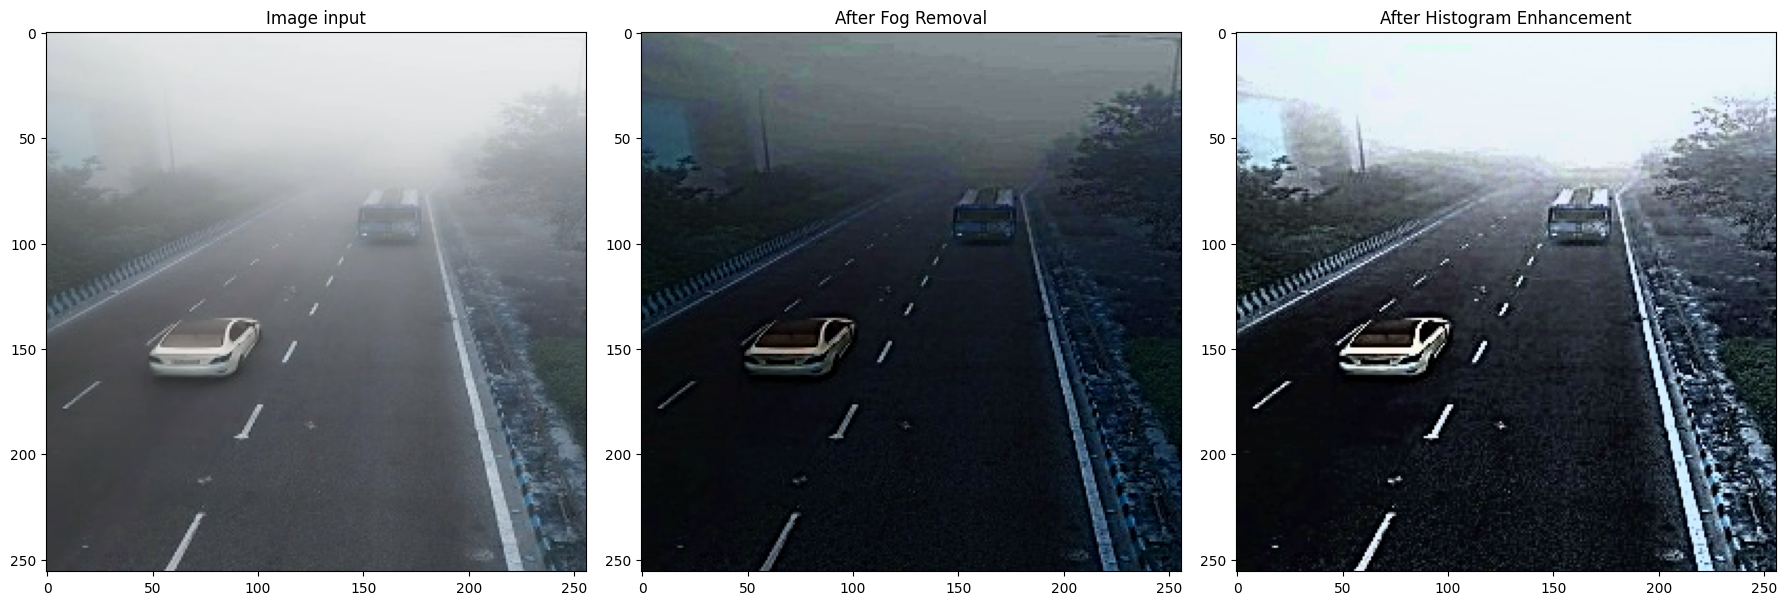

In [17]:
plt.figure(figsize=(18,6))

plt.subplot(131)
plt.title("Image input")
plt.imshow(img)

plt.subplot(132)
plt.title("After Fog Removal")
plt.imshow(img_c)

plt.subplot(133)
plt.title("After Histogram Enhancement")
plt.imshow(img_output)

plt.tight_layout()
plt.show()

In [18]:
#save img_output
cv2.imwrite('img_output.jpg', img_output)

True

In [22]:
def full_pipeline(img):

    img_eq = equalise_hist_color(img)

    airmap = initialize_airmap(img_eq, beta=0.9)
    refined_airmap = refine_airmap(airmap) / 255.0

    refined_airmap = np.clip(refined_airmap, 0.1, 0.9)

    b, g, r = cv2.split(img_eq)

    b_c = restoration(b/255.0, refined_airmap)
    g_c = restoration(g/255.0, refined_airmap)
    r_c = restoration(r/255.0, refined_airmap)

    img_c = cv2.merge((b_c, g_c, r_c))
    img_c = (np.clip(img_c, 0, 1) * 255).astype('uint8')

    img_yuv = cv2.cvtColor(img_c, cv2.COLOR_BGR2YUV)
    img_yuv[:, :, 0] = hist_stretch(img_yuv[:, :, 0])

    img_output = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

    return img_output

In [20]:
input_folder = "/content/real_frames"
output_folder = "/content/output_dataset1"

In [23]:
from glob import glob
import os
import cv2

input_folder = "/content/real_frames"
output_folder = "/content/all_output"

os.makedirs(output_folder, exist_ok=True)

image_paths = sorted(glob(os.path.join(input_folder, "*.jpg")))

print("Total frames:", len(image_paths))

for i, path in enumerate(image_paths):

    img = cv2.imread(path)

    if img is None:
        print("Skipping:", path)
        continue

    result = full_pipeline(img)

    filename = os.path.basename(path)
    save_path = os.path.join(output_folder, filename)

    cv2.imwrite(save_path, result)

    # progress print
    if i % 5 == 0:
        print(f"Processed {i}/{len(image_paths)}")

print("✅ ALL frames processed successfully!")

Total frames: 2728
Processed 0/2728
Processed 50/2728
Processed 100/2728
Processed 150/2728
Processed 200/2728
Processed 250/2728
Processed 300/2728
Processed 350/2728
Processed 400/2728
Processed 450/2728
Processed 500/2728
Processed 550/2728
Processed 600/2728
Processed 650/2728
Processed 700/2728
Processed 750/2728
Processed 800/2728
Processed 850/2728
Processed 900/2728
Processed 950/2728
Processed 1000/2728
Processed 1050/2728
Processed 1100/2728
Processed 1150/2728
Processed 1200/2728
Processed 1250/2728
Processed 1300/2728
Processed 1350/2728
Processed 1400/2728
Processed 1450/2728
Processed 1500/2728
Processed 1550/2728
Processed 1600/2728
Processed 1650/2728
Processed 1700/2728
Processed 1750/2728
Processed 1800/2728
Processed 1850/2728
Processed 1900/2728
Processed 1950/2728
Processed 2000/2728
Processed 2050/2728
Processed 2100/2728
Processed 2150/2728
Processed 2200/2728
Processed 2250/2728
Processed 2300/2728
Processed 2350/2728
Processed 2400/2728
Processed 2450/2728
Proc

In [24]:
dataset_name = filename.split("_frame")[0]

dataset_folder = os.path.join(output_folder, dataset_name)
os.makedirs(dataset_folder, exist_ok=True)

save_path = os.path.join(dataset_folder, filename)

In [25]:
import cv2
import os
from collections import defaultdict

input_folder = "/content/all_output"
video_output_folder = "/content/videos"

os.makedirs(video_output_folder, exist_ok=True)


dataset_frames = defaultdict(list)

for file in os.listdir(input_folder):
    if file.endswith(".jpg"):
        dataset_name = file.split("_frame")[0]
        dataset_frames[dataset_name].append(file)


for dataset_name, files in dataset_frames.items():

    print(f"🎬 Creating video for {dataset_name}...")

    files = sorted(files)

    first_frame = cv2.imread(os.path.join(input_folder, files[0]))
    height, width, _ = first_frame.shape

    video_path = os.path.join(video_output_folder, f"{dataset_name}.mp4")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(video_path, fourcc, 30, (width, height))

    for file in files:
        frame_path = os.path.join(input_folder, file)
        frame = cv2.imread(frame_path)

        if frame is None:
            print("Skipping:", file)
            continue

        out.write(frame)

    out.release()

    print(f"✅ Saved: {video_path}")

print("🎉 All dataset videos created!")

🎬 Creating video for Dataset10...
✅ Saved: /content/videos/Dataset10.mp4
🎬 Creating video for Dataset4...
✅ Saved: /content/videos/Dataset4.mp4
🎬 Creating video for Dataset1...
✅ Saved: /content/videos/Dataset1.mp4
🎬 Creating video for Dataset2...
✅ Saved: /content/videos/Dataset2.mp4
🎬 Creating video for Dataset3...
✅ Saved: /content/videos/Dataset3.mp4
🎬 Creating video for Dataset7...
✅ Saved: /content/videos/Dataset7.mp4
🎬 Creating video for Dataset5...
✅ Saved: /content/videos/Dataset5.mp4
🎬 Creating video for Dataset6...
✅ Saved: /content/videos/Dataset6.mp4
🎬 Creating video for Dataset8...
✅ Saved: /content/videos/Dataset8.mp4
🎬 Creating video for Dataset9...
✅ Saved: /content/videos/Dataset9.mp4
🎉 All dataset videos created!


In [26]:
!zip -r videos.zip /content/videos

  adding: content/videos/ (stored 0%)
  adding: content/videos/Dataset7.mp4 (deflated 0%)
  adding: content/videos/Dataset4.mp4 (deflated 1%)
  adding: content/videos/Dataset2.mp4 (deflated 0%)
  adding: content/videos/Dataset1.mp4 (deflated 1%)
  adding: content/videos/Dataset5.mp4 (deflated 1%)
  adding: content/videos/Dataset10.mp4 (deflated 1%)
  adding: content/videos/Dataset6.mp4 (deflated 1%)
  adding: content/videos/Dataset8.mp4 (deflated 1%)
  adding: content/videos/Dataset9.mp4 (deflated 1%)
  adding: content/videos/Dataset3.mp4 (deflated 1%)


In [27]:
from google.colab import files
files.download("videos.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>